In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install timm medpy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 8.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 18.8 MB/s eta 0:00:00


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF
from sklearn.model_selection import train_test_split
from tqdm import tqdm

from timm.models.layers import DropPath
from medpy.metric.binary import hd95, asd

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [ ]:
torch.backends.cudnn.benchmark = True

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

Device: cuda


In [ ]:
data_root = "/content/drive/MyDrive/ISIC 2017"

image_folder = os.path.join(data_root, "ISIC-2017_Validation")
mask_folder = os.path.join(data_root, "ISIC-2017_Validation_GroundTruth")

print("Image folder exists:", os.path.exists(image_folder))
print("Mask folder exists :", os.path.exists(mask_folder))

Image folder exists: True
Mask folder exists : True


In [ ]:
def build_pairs(image_folder, mask_folder):
    image_files = sorted([
        f for f in os.listdir(image_folder)
        if f.lower().endswith(".jpg") and not f.startswith(".")
    ])

    mask_files = set([
        f for f in os.listdir(mask_folder)
        if f.lower().endswith(".png") and not f.startswith(".")
    ])

    pairs = []
    missing_masks = []

    for img_name in image_files:
        base = os.path.splitext(img_name)[0]
        mask_name = base + "_segmentation.png"

        img_path = os.path.join(image_folder, img_name)
        mask_path = os.path.join(mask_folder, mask_name)

        if mask_name in mask_files:
            pairs.append((img_path, mask_path))
        else:
            missing_masks.append((img_name, mask_name))

    print("JPG images found   :", len(image_files))
    print("PNG masks found    :", len(mask_files))
    print("Valid pairs found  :", len(pairs))
    print("Missing masks count:", len(missing_masks))

    if missing_masks:
        print("\nFirst 10 missing examples:")
        for item in missing_masks[:10]:
            print(item)

    return pairs

pairs = build_pairs(image_folder, mask_folder)

JPG images found   : 150
PNG masks found    : 150
Valid pairs found  : 150
Missing masks count: 0


In [ ]:
random.shuffle(pairs)
pairs = pairs[:150]
print("Using subset size:", len(pairs))

Using subset size: 150


In [ ]:
train_pairs, temp_pairs = train_test_split(
    pairs,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

val_pairs, test_pairs = train_test_split(
    temp_pairs,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("Train:", len(train_pairs))
print("Val  :", len(val_pairs))
print("Test :", len(test_pairs))

Train: 105
Val  : 22
Test : 23


In [ ]:
class ISICSegDataset(Dataset):
    def __init__(self, pairs, image_size=128, train=False):
        self.pairs = pairs
        self.image_size = image_size
        self.train = train

        self.mean = [0.485, 0.456, 0.406]
        self.std = [0.229, 0.224, 0.225]

    def __len__(self):
        return len(self.pairs)

    def augment(self, image, mask):
        if random.random() > 0.5:
            image = TF.hflip(image)
            mask = TF.hflip(mask)

        if random.random() > 0.5:
            image = TF.vflip(image)
            mask = TF.vflip(mask)

        if random.random() > 0.5:
            angle = random.choice([90, 180, 270])
            image = TF.rotate(image, angle)
            mask = TF.rotate(mask, angle)

        return image, mask

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image = image.resize((self.image_size, self.image_size), Image.BILINEAR)
        mask = mask.resize((self.image_size, self.image_size), Image.NEAREST)

        if self.train:
            image, mask = self.augment(image, mask)

        image = TF.to_tensor(image)
        image = TF.normalize(image, mean=self.mean, std=self.std)

        mask = TF.to_tensor(mask)
        mask = (mask > 0.5).float()

        return image, mask

In [ ]:
IMAGE_SIZE = 256
BATCH_SIZE = 4
NUM_WORKERS = 2

train_dataset = ISICSegDataset(train_pairs, image_size=IMAGE_SIZE, train=True)
val_dataset   = ISICSegDataset(val_pairs, image_size=IMAGE_SIZE, train=False)
test_dataset  = ISICSegDataset(test_pairs, image_size=IMAGE_SIZE, train=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

Train batches: 27
Val batches  : 6
Test batches : 6


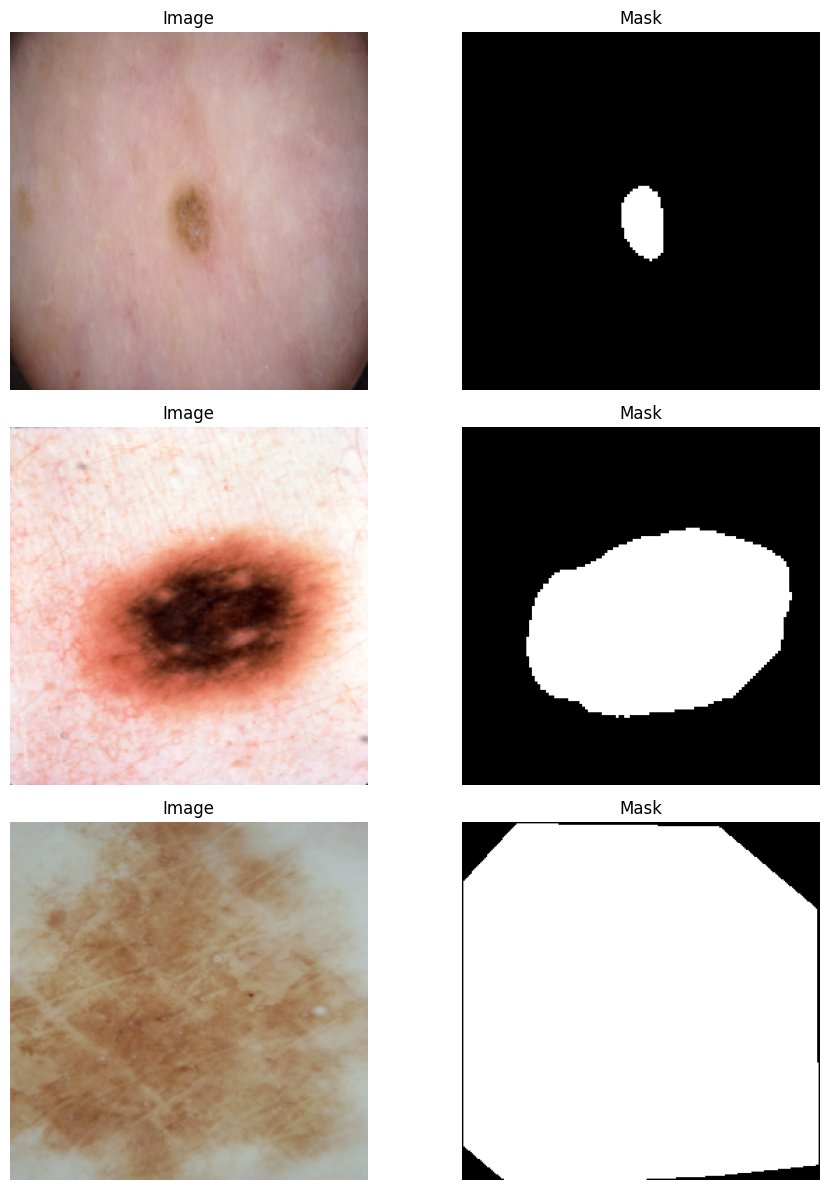

In [ ]:
def denormalize(img):
    mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
    std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
    img = img * std + mean
    return np.clip(img, 0, 1)

def show_samples(dataset, n=3):
    plt.figure(figsize=(10, 4 * n))

    for i in range(n):
        image, mask = dataset[i]
        image_np = denormalize(image.numpy()).transpose(1, 2, 0)
        mask_np = mask.squeeze().numpy()

        plt.subplot(n, 2, 2 * i + 1)
        plt.imshow(image_np)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(n, 2, 2 * i + 2)
        plt.imshow(mask_np, cmap="gray")
        plt.title("Mask")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(train_dataset, n=3)

In [ ]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1):
        super().__init__()

        self.enc1 = DoubleConv(in_ch, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, out_ch, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

In [ ]:
model = UNet(in_ch=3, out_ch=1).to(device)

In [ ]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)

        probs = probs.view(probs.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        intersection = (probs * targets).sum(dim=1)
        union = probs.sum(dim=1) + targets.sum(dim=1)

        dice = (2.0 * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()


class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, logits, targets):
        return self.bce(logits, targets) + self.dice(logits, targets)

criterion = BCEDiceLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=2, factor=0.5)
scaler = torch.cuda.amp.GradScaler()

/tmp/ipykernel_3276/4026270.py:31: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [ ]:
def dice_score(preds, targets, smooth=1e-6):
    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1)

    dice = (2.0 * intersection + smooth) / (union + smooth)
    return dice.mean().item()

def iou_score(preds, targets, smooth=1e-6):
    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1) - intersection

    iou = (intersection + smooth) / (union + smooth)
    return iou.mean().item()

def pixel_accuracy(preds, targets):
    correct = (preds == targets).float().sum()
    total = torch.numel(preds)
    return (correct / total).item()

def hd95_metric(preds, targets):
    vals = []
    preds = preds.cpu().numpy().astype(np.uint8)
    targets = targets.cpu().numpy().astype(np.uint8)

    for p, t in zip(preds, targets):
        p = p.squeeze()
        t = t.squeeze()
        if p.sum() > 0 and t.sum() > 0:
            vals.append(hd95(p, t))
    return np.mean(vals) if len(vals) > 0 else 0.0

def asd_metric(preds, targets):
    vals = []
    preds = preds.cpu().numpy().astype(np.uint8)
    targets = targets.cpu().numpy().astype(np.uint8)

    for p, t in zip(preds, targets):
        p = p.squeeze()
        t = t.squeeze()
        if p.sum() > 0 and t.sum() > 0:
            vals.append(asd(p, t))
    return np.mean(vals) if len(vals) > 0 else 0.0

In [ ]:
THRESHOLD = 0.5

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    pbar = tqdm(loader, desc="Training", leave=False)

    for images, masks in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    return {"loss": running_loss / len(loader)}


@torch.no_grad()
def evaluate(model, loader, criterion, device, threshold=0.5):
    model.eval()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    running_acc = 0.0
    running_hd95 = 0.0
    running_asd = 0.0

    pbar = tqdm(loader, desc="Evaluating", leave=False)

    for images, masks in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, masks)

        probs = torch.sigmoid(outputs)
        preds = (probs > threshold).float()

        running_loss += loss.item()
        running_dice += dice_score(preds, masks)
        running_iou += iou_score(preds, masks)
        running_acc += pixel_accuracy(preds, masks)
        running_hd95 += hd95_metric(preds, masks)
        running_asd += asd_metric(preds, masks)

    n = len(loader)
    return {
        "loss": running_loss / n,
        "dice": running_dice / n,
        "iou": running_iou / n,
        "acc": running_acc / n,
        "hd95": running_hd95 / n,
        "asd": running_asd / n
    }

In [ ]:
EPOCHS = 50
SAVE_PATH = "/content/best_msca_lsb_isic.pth"

history = {
    "train_loss": [],
    "val_loss": [],
    "val_dice": [],
    "val_iou": [],
    "val_acc": [],
    "val_hd95": [],
    "val_asd": []
}

best_val_dice = 0.0

for epoch in range(EPOCHS):
    print(f"\nEpoch [{epoch + 1}/{EPOCHS}]")

    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = evaluate(model, val_loader, criterion, device, THRESHOLD)

    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_dice"].append(val_metrics["dice"])
    history["val_iou"].append(val_metrics["iou"])
    history["val_acc"].append(val_metrics["acc"])
    history["val_hd95"].append(val_metrics["hd95"])
    history["val_asd"].append(val_metrics["asd"])

    scheduler.step(val_metrics["dice"])

    print(f"Train Loss: {train_metrics['loss']:.4f}")
    print(
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Dice: {val_metrics['dice']:.4f} | "
        f"IoU: {val_metrics['iou']:.4f} | "
        f"Acc: {val_metrics['acc']:.4f} | "
        f"95HD: {val_metrics['hd95']:.4f} | "
        f"ASD: {val_metrics['asd']:.4f}"
    )

    if val_metrics["dice"] > best_val_dice:
        best_val_dice = val_metrics["dice"]
        torch.save(model.state_dict(), SAVE_PATH)
        print("Best model saved.")


Epoch [1/50]


Training:   0%|          | 0/27 [00:00<?, ?it/s]/tmp/ipykernel_3276/3416754549.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Train Loss: 1.2344
Val Loss: 1.2494 | Dice: 0.5342 | IoU: 0.4317 | Acc: 0.8681 | 95HD: 96.2450 | ASD: 48.6894
Best model saved.

Epoch [2/50]


Train Loss: 1.1521
Val Loss: 1.3176 | Dice: 0.4319 | IoU: 0.3115 | Acc: 0.7766 | 95HD: 105.8590 | ASD: 53.8163

Epoch [3/50]


Train Loss: 1.0357
Val Loss: 1.1784 | Dice: 0.5608 | IoU: 0.4331 | Acc: 0.8353 | 95HD: 94.8478 | ASD: 48.9854
Best model saved.

Epoch [4/50]


...

Train Loss: 0.7476
Val Loss: 0.8026 | Dice: 0.7169 | IoU: 0.6098 | Acc: 0.9236 | 95HD: 37.6737 | ASD: 19.3580

Epoch [47/50]


Train Loss: 0.7564
Val Loss: 0.7670 | Dice: 0.7412 | IoU: 0.6382 | Acc: 0.9295 | 95HD: 29.5103 | ASD: 16.5689

Epoch [48/50]


Train Loss: 0.7740
Val Loss: 0.7864 | Dice: 0.7261 | IoU: 0.6188 | Acc: 0.9271 | 95HD: 36.3197 | ASD: 18.1098

Epoch [49/50]


Train Loss: 0.7680
Val Loss: 0.7417 | Dice: 0.7469 | IoU: 0.6392 | Acc: 0.9398 | 95HD: 29.7615 | ASD: 15.2115

Epoch [50/50]


Train Loss: 0.7717
Val Loss: 0.7246 | Dice: 0.7544 | IoU: 0.6496 | Acc: 0.9420 | 95HD: 26.2531 | ASD: 11.5329


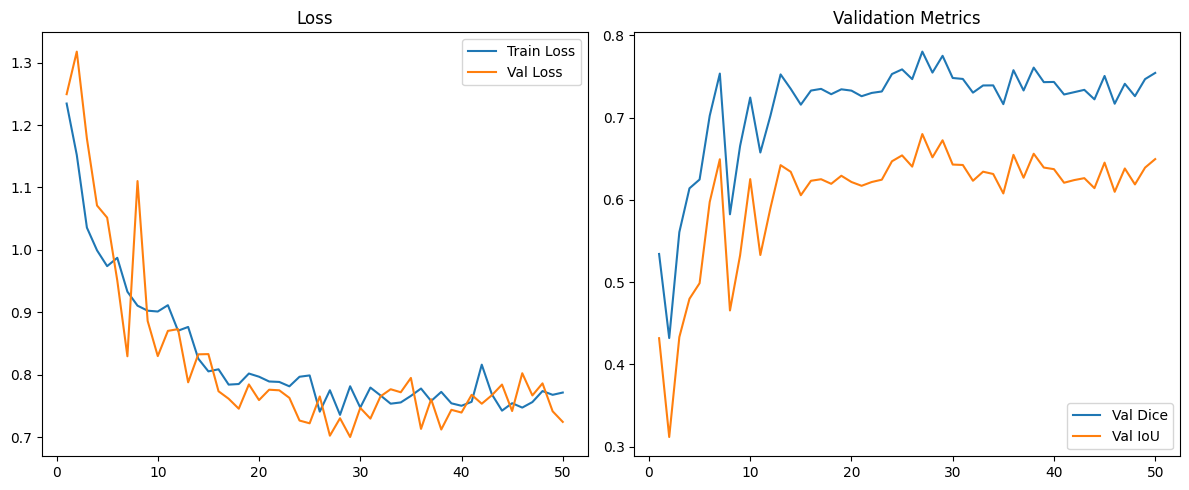

In [ ]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["val_dice"], label="Val Dice")
plt.plot(epochs_range, history["val_iou"], label="Val IoU")
plt.title("Validation Metrics")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()
print("Best model loaded.")

Best model loaded.


In [ ]:
test_metrics = evaluate(model, test_loader, criterion, device, THRESHOLD)

print("\nTest Results")
print(f"Loss : {test_metrics['loss']:.4f}")
print(f"Dice : {test_metrics['dice']:.4f}")
print(f"IoU  : {test_metrics['iou']:.4f}")
print(f"Acc  : {test_metrics['acc']:.4f}")
print(f"95HD : {test_metrics['hd95']:.4f}")
print(f"ASD  : {test_metrics['asd']:.4f}")


Test Results
Loss : 0.7695
Dice : 0.6501
IoU  : 0.5417
Acc  : 0.9135
95HD : 33.2390
ASD  : 16.4615


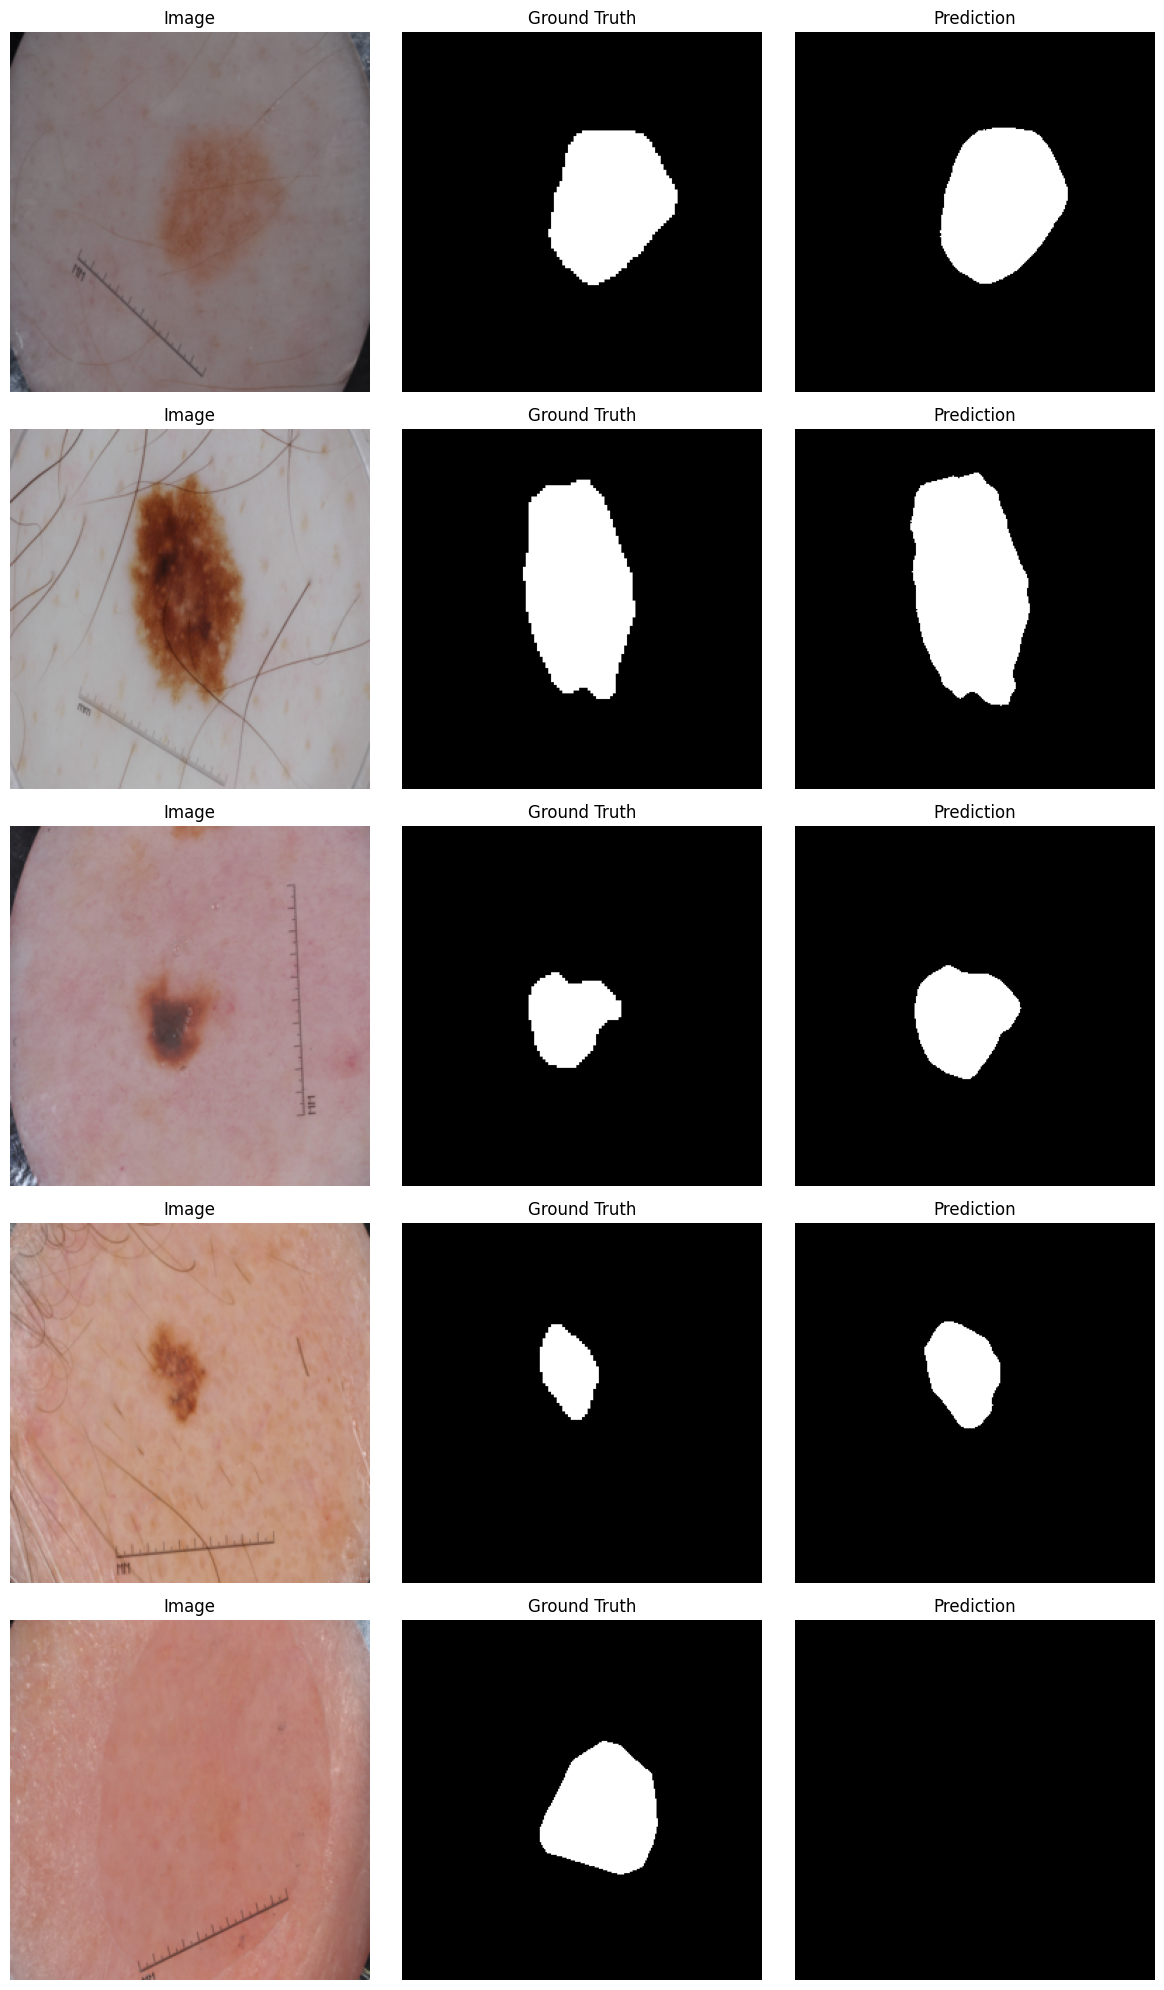

In [ ]:
@torch.no_grad()
def show_predictions(model, dataset, device, num_samples=5, threshold=0.5):
    model.eval()

    indices = np.random.choice(len(dataset), num_samples, replace=False)
    plt.figure(figsize=(12, 4 * num_samples))

    for i, idx in enumerate(indices):
        image, mask = dataset[idx]
        input_tensor = image.unsqueeze(0).to(device)

        output = model(input_tensor)
        prob = torch.sigmoid(output).squeeze().cpu().numpy()
        pred = (prob > threshold).astype(np.float32)

        image_np = denormalize(image.numpy()).transpose(1, 2, 0)
        mask_np = mask.squeeze().numpy()

        plt.subplot(num_samples, 3, 3 * i + 1)
        plt.imshow(image_np)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(num_samples, 3, 3 * i + 2)
        plt.imshow(mask_np, cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(num_samples, 3, 3 * i + 3)
        plt.imshow(pred, cmap="gray")
        plt.title("Prediction")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_predictions(model, test_dataset, device, num_samples=5, threshold=THRESHOLD)

In [ ]:
results_df = pd.DataFrame([test_metrics])
results_df

,loss,dice,iou,acc,hd95,asd
0,0.769521,0.650109,0.541748,0.913485,33.239029,16.461471


In [ ]:
results_df.to_csv("/content/isic_test_results.csv", index=False)
print("Saved to /content/isic_test_results.csv")

Saved to /content/isic_test_results.csv
